# B-3001 · Construccion de features

Genera `b3001_features.parquet` (formato tidy: 1 fila = timestamp x tubo) con los bloques de
variables para los tres criterios: **prediccion termica**, **deteccion de anomalias** y
**riesgo / vida remanente**.

**Orden de ejecucion:** celdas 1 -> 8, en secuencia.
La celda 4 cachea los datos limpios en `data/`: en sesiones posteriores el notebook arranca
desde el cache y se salta la lectura del Excel (~30-60 s).

**Ventana de analisis:** el historico completo (2008 ->) se usa para las acumuladas de creep y
el calentamiento de las ventanas moviles, pero las filas exportadas se recortan a
`DATA_START` (por defecto **2024-10-01**) en adelante. Ver celda 3.

**Recursos:** entorno CPU estandar basta. Pico de RAM ~3 GB.


## 1. Entorno y dependencias

In [1]:
# Dependencias minimas: pandas, numpy, matplotlib, pyarrow (parquet) y openpyxl (lectura del Excel).
import importlib, subprocess, sys
for pkg in ["pyarrow", "openpyxl"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})
print("pandas", pd.__version__, "| numpy", np.__version__)


pandas 3.0.5 | numpy 2.5.1


## 2. Rutas locales

El proyecto ya tiene la estructura en disco: el Excel vive en `data/`, las features en
`features/` y los CSV/figuras en `reportes/`. `BASE` se resuelve desde el propio notebook,
asi que no hay que tocar nada si se ejecuta desde la carpeta del proyecto.


In [2]:
from pathlib import Path

# Raiz del proyecto: la carpeta donde vive este notebook.
BASE    = Path.cwd()
DATA    = BASE / "data"
FEATURES = BASE / "features"
REPORTES = BASE / "reportes"
for d in (DATA, FEATURES, REPORTES):
    d.mkdir(parents=True, exist_ok=True)

XLSX      = DATA / "Dataset_T\u00b0C_B-3001.xlsx"       # entrada
CACHE_VAL = DATA / "cache_vals.parquet"               # temperaturas limpias
CACHE_SAT = DATA / "cache_sat.parquet"                # flags de saturacion
OUT_FEAT  = FEATURES / "b3001_features.parquet"       # salida principal
OUT_CORR  = REPORTES / "correlaciones_features.csv"
OUT_STOPS = REPORTES / "detenciones.csv"

assert XLSX.exists(), f"No encuentro {XLSX}. Ejecuta el notebook desde la raiz del proyecto o corrige BASE."
print("Excel:", round(XLSX.stat().st_size/1e6, 1), "MB")


Excel: 71.1 MB


## 3. Configuracion

Parametros de limpieza, deteccion de estados y creep (material T9, API 530), mas el mapeo
de tags. Los tubos rotulados `P1.1` / `P2.1` en el archivo original corresponden a **P3 / P4**.

In [3]:
# --- Limpieza y estados ---
SAT_LIMITE   = 700.0     # >700 C = saturacion (clamp del historiador), no es medicion
RUN_TH       = 250.0     # mediana CONV >= 250 C -> operacion
STOP_TH      = 150.0     # mediana CONV <  150 C -> detencion fria
GAP_CIERRE_H = 6         # huecos <=6 h dentro de un STOP se cierran
MERGE_H      = 24        # detenciones separadas <24 h se fusionan
MIN_STOP_H   = 4         # minimo de horas frias reales para contar el episodio

# --- Creep: material T9, API 530 ---
CLM, A_MAT, FCR   = 20.946, 8.15e5, 1.0
T_LIM             = 705.0
DO, T_MIN, T_PROM = 108.0, 12.1, 12.1
CA                = 3.0
P_MPA             = 57.2 * 0.0981
VIDA_DISENO_H     = 100_000.0
TMT_NORMAL, TMT_DISENO, TMT_UMBRAL = 634.0, 705.0, 840.0

DM        = DO - T_PROM
SIGMA_H   = (P_MPA * DM) / (2 * T_PROM)                                    # 22.24 MPa
LMP_SIGMA = (TMT_DISENO + 273.15) * (CLM + np.log10(VIDA_DISENO_H)) / 1000  # ancla iso-esfuerzo

# --- Mapeo tag -> (paso, punto) ---
MAPPING = {
 "TI_30021.pv":("P1","CONV"),
 "TI_30017A.pv":("P1","T1 SP"), "TI_30017D.pv":("P1","T1 SO"),
 "TI_30017B.pv":("P1","T5 SP"), "TI_30017E.pv":("P1","T5 SO"),
 "TI_30017C.pv":("P1","T10 NP"),"TI_30017F.pv":("P1","T10 NO"),
 "TI_30022.pv":("P2","CONV"),
 "TI_30018A.pv":("P2","T1 NP"), "TI_30018D.pv":("P2","T1 NO"),
 "TI_30018B.pv":("P2","T5 NP"), "TI_30018E.pv":("P2","T5 NO"),
 "TI_30018C.pv":("P2","T10 SP"),"TI_30018F.pv":("P2","T10 SO"),
 "TI_30033.pv":("P3","CONV"),
 "TI_30031A.pv":("P3","T1 SP"), "TI_30031D.pv":("P3","T1 SO"),
 "TI_30031B.pv":("P3","T5 SP"), "TI_30031E.pv":("P3","T5 SO"),
 "TI_30031C.pv":("P3","T10 NP"),"TI_30031F.pv":("P3","T10 NO"),
 "TI_30034.pv":("P4","CONV"),
 "TI_30032A.pv":("P4","T1 NP"), "TI_30032D.pv":("P4","T1 NO"),
 "TI_30032B.pv":("P4","T5 NP"), "TI_30032E.pv":("P4","T5 NO"),
 "TI_30032C.pv":("P4","T10 SP"),"TI_30032F.pv":("P4","T10 SO"),
 "TC_30028.pv":("CTRL","P4"), "TC_30027.pv":("CTRL","P3"),
 "TC_30020.pv":("CTRL","P2"), "TC_30019.pv":("CTRL","P1"),
}
PASOS  = ["P1", "P2", "P3", "P4"]
TAGS   = list(MAPPING)
CONV   = {p: [c for c,(pp,n) in MAPPING.items() if pp==p and n=="CONV"][0] for p in PASOS}
TUBES  = {p: [c for c,(pp,n) in MAPPING.items() if pp==p and n!="CONV"]     for p in PASOS}
CTRL   = {v[1]: k for k,v in MAPPING.items() if v[0]=="CTRL"}
NOMBRE = lambda c: f"{MAPPING[c][0]} {MAPPING[c][1]}"

print(f"sigma_h = {SIGMA_H:.2f} MPa | LMP_sigma = {LMP_SIGMA:.4f} | tubos = {sum(len(v) for v in TUBES.values())}")

# --- Ventana temporal de analisis ---
# El pipeline procesa TODO el historico (las acumuladas de creep y las ventanas moviles de 30 d
# necesitan el pasado completo) y recorta las filas exportadas al final del proceso.
DATA_START = pd.Timestamp("2020-10-01")   # inicio de la ventana de estudio
DATA_END   = pd.Timestamp("2024-10-01")   # None = hasta el ultimo dato disponible
print(f"Ventana de analisis: {DATA_START.date()} -> {DATA_END.date() if DATA_END is not None else 'ultimo dato'}")

sigma_h = 22.24 MPa | LMP_sigma = 25.3791 | tubos = 24
Ventana de analisis: 2020-10-01 -> 2024-10-01


## 4. Carga y limpieza (con cache)

Reglas aplicadas: etiquetas de texto del historiador (`[-11059] No Good Data For Calculation`,
etc.) -> `NaN`; valores >700 C -> flag `sat` y `NaN` en temperatura; grilla horaria continua
para que los huecos queden explicitos; timestamps duplicados eliminados.

El cache guarda el historico **completo** en `data/*.parquet`. El recorte a `DATA_START` se
aplica recien en la celda 6, de modo que cambiar la ventana no obliga a releer el Excel.
La primera ejecucion lee el Excel (~30-60 s); las siguientes cargan el parquet.


In [4]:
def carga_y_limpieza(ruta_xlsx):
    df = pd.read_excel(ruta_xlsx, sheet_name=0, header=0)
    df = df.iloc[3:].rename(columns={"Unnamed: 0": "ts"})       # 3 filas de metadatos
    df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
    df = (df.dropna(subset=["ts"])
            .drop_duplicates("ts", keep="first")
            .sort_values("ts").set_index("ts"))
    for c in TAGS:
        df[c] = pd.to_numeric(df[c], errors="coerce")            # texto -> NaN
    grid = pd.date_range(df.index.min(), df.index.max(), freq="h")
    df   = df.reindex(grid)
    sat  = (df[TAGS] > SAT_LIMITE)
    vals = df[TAGS].where(~sat).astype("float32")
    return vals, sat

if CACHE_VAL.exists() and CACHE_SAT.exists():
    vals = pd.read_parquet(CACHE_VAL)
    sat  = pd.read_parquet(CACHE_SAT).astype(bool)
    print("Cache cargado.")
else:
    vals, sat = carga_y_limpieza(XLSX)
    vals.to_parquet(CACHE_VAL); sat.to_parquet(CACHE_SAT)
    print("Excel procesado y cacheado en data/.")

print(f"Rango completo: {vals.index.min()} -> {vals.index.max()}  ({len(vals):,} horas)")
en_ventana = vals.index >= DATA_START
if DATA_END is not None:
    en_ventana &= vals.index <= DATA_END
print(f"Dentro de la ventana: {int(en_ventana.sum()):,} horas "
      f"({int(en_ventana.sum())/24:,.0f} dias)")
print(f"Celdas saturadas (>700 C): {int(sat.values.sum()):,}")
vals.iloc[:3, :5]

Cache cargado.
Rango completo: 2008-06-05 15:00:00 -> 2026-01-30 14:00:00  (154,752 horas)
Dentro de la ventana: 35,065 horas (1,461 dias)
Celdas saturadas (>700 C): 95,443


,TI_30021.pv,TI_30017A.pv,TI_30017D.pv,TI_30017B.pv,TI_30017E.pv
2008-06-05 15:00:00,428.760529,363.650085,355.366028,377.666840,379.216278
2008-06-05 16:00:00,429.519043,361.160065,351.047791,374.385895,375.311188
2008-06-05 17:00:00,430.644379,357.466003,344.641418,369.518402,369.517731


## 5. Estado de operacion y detenciones

`h_desde_arranque` depende de las detenciones, asi que hay que calcularlas antes de las features.
El estado sale de la mediana de las cuatro CONV; se cierran huecos cortos y se fusionan
episodios separados por menos de 24 h para no contar un mismo evento dos veces.

In [5]:
def _episodios(mask, min_h=1):
    """Segmentos True contiguos -> [(inicio, fin, horas)]."""
    grp, out = (mask != mask.shift()).cumsum(), []
    for _, idx in mask.groupby(grp).groups.items():
        if mask.loc[idx].iloc[0] and len(idx) >= min_h:
            out.append((idx[0], idx[-1], len(idx)))
    return out

def estados_y_detenciones(vals):
    op_ref = vals[list(CONV.values())].median(axis=1)
    op_ref = op_ref.fillna(vals[[t for p in TUBES for t in TUBES[p]]].median(axis=1))
    state  = pd.Series(np.where(op_ref >= RUN_TH, "RUN",
                       np.where(op_ref <  STOP_TH, "STOP", "TRANS")), index=vals.index)
    state[op_ref.isna()] = "NODATA"

    s   = (state == "STOP").astype(int)
    s2  = s.rolling(2*GAP_CIERRE_H + 1, center=True, min_periods=1).max().astype(bool)
    eps = []
    for a, b, _ in _episodios(s2):
        if s.loc[a:b].sum() >= MIN_STOP_H:
            eps.append([a, b, (b-a).total_seconds()/3600 + 1, op_ref.loc[a:b].min()])

    merged = []
    for e in sorted(eps):
        if merged and (e[0] - merged[-1][1]).total_seconds()/3600 < MERGE_H:
            merged[-1][1] = e[1]
            merged[-1][2] = (e[1] - merged[-1][0]).total_seconds()/3600 + 1
            merged[-1][3] = min(merged[-1][3], e[3])
        else:
            merged.append(e)

    stops = pd.DataFrame(merged, columns=["inicio","fin","horas","t_min"])
    stops["dias"] = stops.horas / 24
    return op_ref, state, stops

op_ref, state, stops = estados_y_detenciones(vals)
stops.to_csv(OUT_STOPS, index=False)                      # historico completo

# los arranques previos a DATA_START siguen alimentando h_desde_arranque; el resumen es de la ventana
stops_v = stops[stops.fin >= DATA_START]
state_v = state[state.index >= DATA_START]

print(f"Historico  -> detenciones: {len(stops)} | disponibilidad RUN: {(state=='RUN').mean()*100:.1f}%")
print(f"Ventana    -> detenciones: {len(stops_v)} | horas detenido: {stops_v.horas.sum():,.0f} "
      f"| disponibilidad RUN: {(state_v=='RUN').mean()*100:.1f}%")
stops_v.nlargest(5, "dias")[["inicio","fin","dias"]]

Historico  -> detenciones: 32 | disponibilidad RUN: 89.1%
Ventana    -> detenciones: 12 | horas detenido: 4,860 | disponibilidad RUN: 87.7%


,inicio,fin,dias
22,2021-10-11 11:00:00,2022-01-10 04:00:00,90.750000
30,2025-04-02 13:00:00,2025-05-23 01:00:00,50.541667
21,2021-04-16 06:00:00,2021-05-01 12:00:00,15.291667
26,2023-12-24 21:00:00,2024-01-06 06:00:00,12.416667
29,2025-02-26 06:00:00,2025-03-08 00:00:00,9.791667


## 6. Construccion de las features

Se arma en formato **tidy** (1 fila = timestamp x tubo) para entrenar un modelo global con
`tubo` como categorica, en vez de 24 modelos separados. Se procesa tubo por tubo y se
concatena al final para no inflar la RAM.

El calculo corre sobre el historico completo y **recien al final se recorta a `DATA_START`**.
Asi `D_acum`, `h650_acum` y `sat_acum` conservan el dano real acumulado desde 2008 (el creep no
se reinicia) y las ventanas moviles de 24 h / 30 d llegan a la ventana ya calentadas, sin NaN.

| Bloque | Variables | Para que |
|---|---|---|
| Base | `TMT, sat, run, conv_paso, ctrl_paso, h_desde_arranque` | contexto de proceso y ciclo operativo |
| Criterio 1 | `lag_*, roll_mean_24h, roll_std_24h, rampa_*`, objetivo `target_T_24h` | prediccion termica |
| Criterio 2 | `resid_paso, z_resid_30d, flatline_12h, anomalia` | anomalias y desviaciones |
| Criterio 3 | `dano_1h, D_acum, h650_acum, sat_acum` | riesgo y vida remanente |


In [6]:
def t_ruptura(T_c):
    """t_r(T) a sigma_h por Larson-Miller, anclado a 705 C / 100.000 h (API 530, SI)."""
    return 10 ** (LMP_SIGMA*1000/(np.asarray(T_c, dtype="float64") + 273.15) - CLM)

def features(vals, sat, state, stops):
    run = (state == "RUN")

    # horas desde el ultimo arranque: se reinicia al terminar cada detencion
    arranques = pd.Series(0, index=vals.index)
    for fin in stops["fin"]:
        arranques.loc[fin] = 1
    ciclo = arranques.cumsum()
    h_desde_arranque = vals.index.to_series().groupby(ciclo).cumcount().astype("int32")

    frames = []
    for p, cols in TUBES.items():
        med_paso = vals[cols].median(axis=1)                  # mediana: robusta a sensores fallados
        for c in cols:
            T = vals[c]
            f = pd.DataFrame(index=vals.index)
            f["tubo"], f["paso"] = NOMBRE(c), p

            # --- base ---
            f["TMT"]              = T
            f["sat"]              = sat[c].astype("int8")     # flag, nunca temperatura
            f["run"]              = run.astype("int8")
            f["conv_paso"]        = vals[CONV[p]]
            f["ctrl_paso"]        = vals[CTRL[p]]
            f["h_desde_arranque"] = h_desde_arranque.values

            # --- criterio 1: prediccion termica ---
            for L in (1, 3, 6, 24):
                f[f"lag_{L}h"] = T.shift(L)
            f["roll_mean_24h"] = T.rolling(24, min_periods=12).mean()
            f["roll_std_24h"]  = T.rolling(24, min_periods=12).std()
            f["rampa_1h"]      = T.diff()
            f["rampa_6h"]      = T.diff(6) / 6
            f["target_T_24h"]  = T.shift(-24)                 # objetivo t+24 h

            # --- criterio 2: anomalias / desviaciones ---
            f["resid_paso"]   = T - med_paso                  # quita el modo comun del paso
            mu = f["resid_paso"].rolling(24*30, min_periods=24*7).median()
            sd = f["resid_paso"].rolling(24*30, min_periods=24*7).std()
            f["z_resid_30d"]  = (f["resid_paso"] - mu) / sd   # vs su propia historia
            f["flatline_12h"] = (T.rolling(12).std() < 0.05).astype("int8")
            f["anomalia"]     = ((f["z_resid_30d"].abs() > 4) & run).astype("int8")

            # --- criterio 3: riesgo / vida remanente ---
            dano = pd.Series(0.0, index=vals.index)
            m = run & T.notna()
            dano[m] = 1.0 / t_ruptura(T[m])
            dano[run & sat[c]] = 1.0 / t_ruptura(SAT_LIMITE)  # cota inferior en horas ciegas
            f["dano_1h"]   = dano
            f["D_acum"]    = dano.cumsum()
            f["h650_acum"] = ((T > 650) & run).cumsum().astype("int32")
            f["sat_acum"]  = (sat[c] & run).cumsum().astype("int32")

            for col in f.select_dtypes("float64"):
                f[col] = f[col].astype("float32")
            frames.append(f)

    out = pd.concat(frames).reset_index().rename(columns={"index": "ts"})
    out["tubo"] = out["tubo"].astype("category")
    out["paso"] = out["paso"].astype("category")
    return out

feat = features(vals, sat, state, stops)
print(f"Historico completo: {feat.shape[0]:,} filas")

# --- recorte a la ventana de analisis ---
feat = feat[feat.ts >= DATA_START]
if DATA_END is not None:
    feat = feat[feat.ts <= DATA_END]
feat = feat.reset_index(drop=True)

print(f"Ventana ({feat.ts.min()} -> {feat.ts.max()}): "
      f"{feat.shape[0]:,} filas x {feat.shape[1]} columnas | "
      f"RAM: {feat.memory_usage(deep=True).sum()/1e6:.0f} MB")
feat[feat.run == 1].head(3).T

Historico completo: 3,714,048 filas
Ventana (2020-10-01 00:00:00 -> 2024-10-01 00:00:00): 841,560 filas x 26 columnas | RAM: 76 MB


,0,1,2
ts,2020-10-01 00:00:00,2020-10-01 01:00:00,2020-10-01 02:00:00
tubo,P1 T1 SP,P1 T1 SP,P1 T1 SP
paso,P1,P1,P1
TMT,519.318604,519.603699,519.408325
sat,0,0,0
run,1,1,1
conv_paso,423.043213,423.06955,422.302002
ctrl_paso,492.754608,492.720215,493.428711
h_desde_arranque,13751,13752,13753
lag_1h,519.016602,519.318604,519.603699


## 7. Correlaciones entre features

Spearman (monotona, no asume linealidad), calculada **solo sobre horas en operacion** dentro de
la ventana y con muestreo para que corra rapido. Sirve para tres cosas: fijar la vara del
baseline predictivo, verificar que la senal de anomalia es independiente del nivel termico, y
detectar colinealidad antes de entrenar.


In [7]:
FEATS_NUM = ["TMT","conv_paso","ctrl_paso","h_desde_arranque","lag_1h","lag_24h",
             "roll_mean_24h","roll_std_24h","rampa_1h","rampa_6h","resid_paso",
             "z_resid_30d","dano_1h","D_acum","h650_acum","sat_acum",
             "target_T_24h","anomalia","sat"]

def correlaciones(feat, metodo="spearman", solo_run=True, muestra=200_000, seed=0):
    d = feat[feat.run == 1] if solo_run else feat
    if len(d) > muestra:
        d = d.sample(muestra, random_state=seed)
    return d[FEATS_NUM].corr(method=metodo)

corr = correlaciones(feat)
corr.round(3).to_csv(OUT_CORR)

for tgt, lbl in [("target_T_24h","PREDICCION (T a t+24h)"),
                 ("anomalia","ANOMALIAS"),
                 ("dano_1h","RIESGO (dano instantaneo)")]:
    print(f"\n--- {lbl} ---")
    print(corr[tgt].drop(tgt).sort_values(key=abs, ascending=False).head(8).round(3).to_string())


--- PREDICCION (T a t+24h) ---
TMT              0.924
lag_1h           0.921
dano_1h          0.918
roll_mean_24h    0.906
lag_24h          0.876
resid_paso       0.806
h650_acum        0.571
D_acum           0.319

--- ANOMALIAS ---
roll_std_24h        0.159
conv_paso          -0.078
z_resid_30d         0.043
sat                -0.037
ctrl_paso           0.026
rampa_6h            0.021
h_desde_arranque    0.019
rampa_1h            0.017

--- RIESGO (dano instantaneo) ---
TMT              1.000
lag_1h           0.989
roll_mean_24h    0.967
lag_24h          0.926
target_T_24h     0.918
resid_paso       0.827
sat              0.479
D_acum           0.423


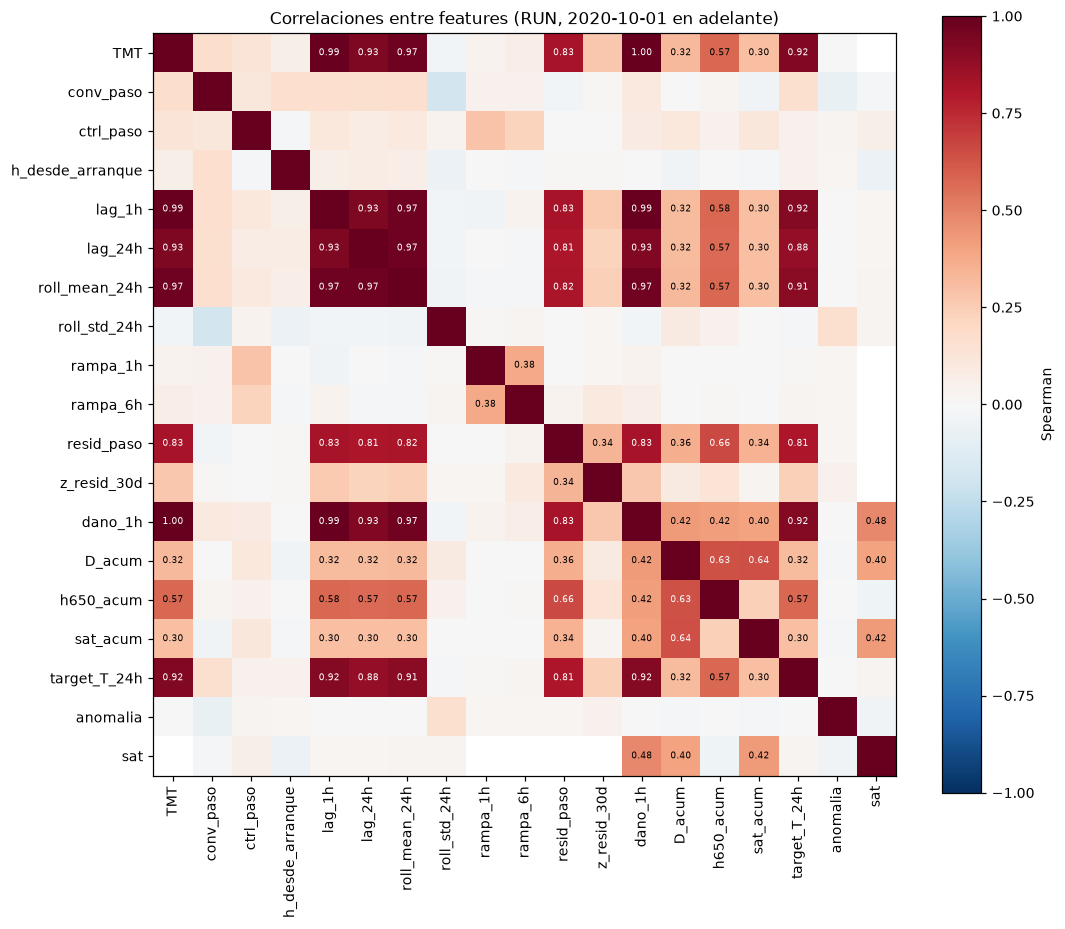

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        if abs(v) >= 0.3 and i != j:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if abs(v) > 0.6 else "black")
ax.grid(False)
plt.colorbar(im, label="Spearman")
ax.set_title(f"Correlaciones entre features (RUN, {DATA_START.date()} -> {DATA_END.date() if DATA_END is not None else 'ultimo dato'})")
plt.tight_layout()
plt.savefig(REPORTES / "fig_correlaciones.png", dpi=150)
plt.show()

## 8. Guardar y verificar

Se escribe el parquet comprimido con zstd (~240 MB) y se corren chequeos de sanidad:
si alguno falla, revisa la celda correspondiente antes de modelar.

In [8]:
feat.to_parquet(OUT_FEAT, compression="zstd", index=False)
print("Guardado:", OUT_FEAT, f"({OUT_FEAT.stat().st_size/1e6:.0f} MB)")

# --- chequeos de sanidad ---
r = feat[feat.run == 1]
assert feat.TMT.max() <= SAT_LIMITE, "Hay temperaturas >700 C: la saturacion no se filtro"
assert feat.groupby("tubo", observed=True).D_acum.max().max() < 1, "Algun D_acum >= 1: revisar creep"
print(f"Ventana: {feat.ts.min():%Y-%m-%d} -> {feat.ts.max():%Y-%m-%d}")
print(f"Tubos: {feat.tubo.nunique()} | horas RUN por tubo: {len(r)//feat.tubo.nunique():,}")
print(f"TMT en operacion -> P50 {r.TMT.median():.0f} C | P95 {r.TMT.quantile(.95):.0f} C | max {r.TMT.max():.0f} C")
print(f"Anomalias marcadas: {int(r.anomalia.sum()):,} ({r.anomalia.mean()*100:.2f}% de las horas RUN)")

print("\nTop 5 tubos por dano acumulado (Robinson):")
print(feat.groupby("tubo", observed=True)
          .agg(D_acum=("D_acum","max"), h_sat=("sat_acum","max"), h650=("h650_acum","max"))
          .nlargest(5, "D_acum").round(4).to_string())

Guardado: /Users/bencourtin/Developer/projects/Tesis_HornoB3001/features/b3001_features.parquet (18 MB)
Ventana: 2024-10-01 -> 2026-01-30
Tubos: 24 | horas RUN por tubo: 9,813
TMT en operacion -> P50 556 C | P95 655 C | max 700 C
Anomalias marcadas: 3,369 (1.43% de las horas RUN)

Top 5 tubos por dano acumulado (Robinson):
           D_acum  h_sat   h650
tubo                           
P2 T1 NO   0.1515  18043  12565
P3 T5 SP   0.1281  17120   1776
P2 T5 NP   0.1158  15598    654
P1 T10 NP  0.1088  14666    637
P2 T10 SO  0.0982  13276    185


---

### Notas de uso

- **Filtra siempre `run == 1`** antes de entrenar: las horas de detencion son fisica distinta
  (enfriamiento sin fuego ni flujo) y contaminan cualquier modelo termico.
- **Validacion temporal, nunca aleatoria.** Con lags de 1 h y correlaciones de 0.9+, un split
  aleatorio filtra informacion del futuro y da metricas irreales. Entrena hasta una fecha de
  corte y evalua en el periodo posterior.
- **Baseline obligatorio:** persistencia (`lag_24h` como prediccion). Si el modelo no lo supera,
  no esta aprendiendo nada del proceso.
- **Colinealidad:** `TMT`, los lags y `roll_mean_24h` forman un bloque con rho > 0.9. Para
  modelos lineales o interpretabilidad con SHAP, elige un representante por bloque o regulariza.
- **No uses `dano_1h` junto a `TMT`** como predictores: el primero es funcion monotona del
  segundo por construccion.
- Las acumuladas (`D_acum`, `h650_acum`, `sat_acum`) son monotonas crecientes y **arrastran el
  historico desde 2008**, no solo la ventana: sirven como estado de criticidad inicial, no como
  features de un modelo hora a hora sin diferenciar.
- El modelo base de vida util remanente vive en `B3001_RUL_random_forest.ipynb`, que consume
  este parquet.
